<a href="https://colab.research.google.com/github/priyal-rgb/ML-and-GenAI-Assignment/blob/main/Week3_Assignment1_EDA_and_ML_on_Agricultural_Yield_Dataset_Priyal_Modi_04801192025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
#Part-A: Understanding the Dataset
#Q1 - Dataset Overview
!pip install pandas --quiet
import pandas as pd

df=pd.read_csv("agriculture_yield_dataset.csv")

print("Shape:", df.shape)

print("Columns:", list(df.columns))

print(df.head(10))

Shape: (1500, 8)
Columns: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3               8.3      5.8   

  crop_type soil

In [72]:
#Q2 - Data Types and Missing Values
print(df.dtypes)

is_missing=df.isnull().values.any()
print()
print(is_missing)

if is_missing==True:
  missing_cols=df.isnull().sum()
  missing_cols=missing_cols[missing_cols>0]
  print(missing_cols)

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

False


In [73]:
#Q3 - Descriptive Statistics
print(df.describe())

max_mean_feature=df.select_dtypes(include="number").mean().idxmax()
print("Feature with highest mean:", max_mean_feature)

max_std_feature=df.select_dtypes(include="number").std().idxmax()
print("Feature with highest standard deviation:", max_std_feature)

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [74]:
#Part-B: Exploratory Data Analysis (EDA)
#Q4 - Distribution Analysis
!pip install plotly --quiet
import plotly.express as px

fig=px.histogram(df, x="rainfall_mm", nbins=30, title="Distribution of Rainfall (in mm)")
fig.update_layout(bargap=0.1)
fig.show()

fig=px.histogram(df, x="temperature_c", nbins=20, title="Distribution of Temperature (in degree Celcius)")
fig.update_layout(bargap=0.1)
fig.show()

fig=px.histogram(df, x="fertilizer_kg", nbins=20, title="Distribution of Fertilizer (in kg)")
fig.update_layout(bargap=0.1)
fig.show()

fig=px.histogram(df, x="yield_ton_per_hectare", nbins=15, title="Distribution of Yield (in ton/hectare)")
fig.update_layout(bargap=0.1)
fig.show()

In [28]:
#Q5 - Crop Type Analysis
crop_count=df.crop_type.value_counts()
print(crop_count)

fig=px.bar(crop_count, title="Count Plot for Crop Type")
fig.update_layout(bargap=0.1)
fig.show()

print(crop_count.idxmax(), "appears most frequently with", crop_count.max(), "records")

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


Cotton appears most frequently with 311 records


In [75]:
#Q6 - Soil Type Analysis
soil_count=df.soil_type.value_counts()
print(soil_count)

fig=px.bar(soil_count, title="Count Plot for Soil Type")
fig.update_layout(bargap=0.1)
fig.show()

print(soil_count.idxmax(), "is most common with", soil_count.max(), "records")

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


Clay is most common with 534 records


Q7 - Yield Distribution

Yes. The distribution is approximately normal. It shows a clear bell-shaped curve that is highly symmetric. The data has peaks in the center between 4.5 and 5.5 tons/hectare and tapers off evenly on both the left and right.

No. There are no noticeable or isolated outliers. The data flows continuously down to about 2 on the left and up to 8 on the right.

In [76]:
#Q8 - Scatter Plot Analysis
fig=px.scatter(df, x="rainfall_mm", y="yield_ton_per_hectare")
fig.show()

fig=px.scatter(df, x="fertilizer_kg", y="yield_ton_per_hectare")
fig.show()

#rainfall_mm has a noticeably stronger relationship with yield
#Clear Upward Trend: In first plot (rainfall_mm vs. yield), the dense cluster of data points clearly slopes upward from left to right. As rainfall increases from 300 mm to 1200 mm, the minimum, average, and maximum yield values all steadily rise.
#Flat Trend: In second plot (fertilizer_kg vs. yield), the data looks like a flat, uniform cloud of dots spread evenly from 50 kg to 250 kg. The overall yield range and average remain almost identical regardless of how much fertilizer is applied, indicating a weak or negligible linear relationship.

Correlation matrix:
                        rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412   

<Axes: >

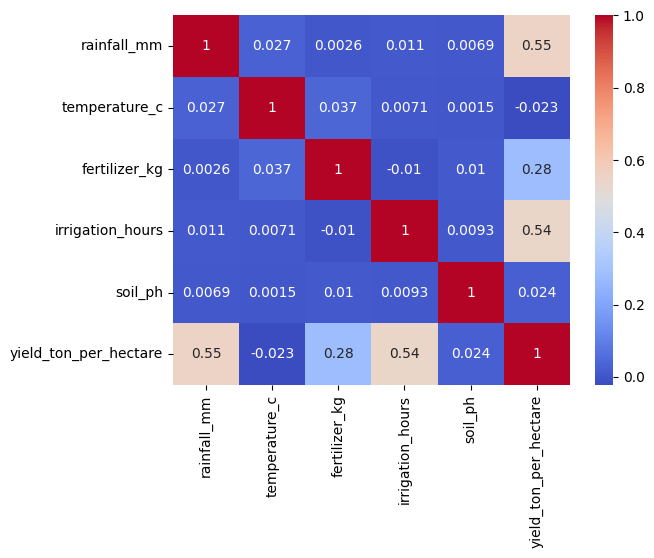

In [77]:
#Q9 - Correlation Analysis
numerical_cols=df.select_dtypes(include="number")
corr_matrix=numerical_cols.corr()
print("Correlation matrix:\n", corr_matrix)

!pip install seaborn --quiet
import seaborn as sns
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True)

In [78]:
print(corr_matrix["yield_ton_per_hectare"].drop("yield_ton_per_hectare").abs().nlargest(3))

rainfall_mm         0.553704
irrigation_hours    0.542664
fertilizer_kg       0.278043
Name: yield_ton_per_hectare, dtype: float64


In [79]:
#Q10 - Group-Based Analysis
crops_average=df.groupby("crop_type")["yield_ton_per_hectare"].mean()
print("Average yield for each crop type\n", crops_average)

soils_average=df.groupby("soil_type")["yield_ton_per_hectare"].mean()
print("Average yield for each soil type\n", soils_average)

print(crops_average.idxmax(), "crop has highest average yield with", crops_average.max(), "tons/hectare")
print(soils_average.idxmax(), "soil has highest average yield with", soils_average.max(), "tons/hectare")

Average yield for each crop type
 crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
Average yield for each soil type
 soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Rice crop has highest average yield with 5.494744027303755 tons/hectare
Loamy soil has highest average yield with 5.366518987341772 tons/hectare


In [80]:
#Part-C: Data Preparation
#Q11 - Feature Encoding
cat_cols=df.select_dtypes(include=["object"]).columns
print(list(cat_cols))

df_encoded=pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded.head()

['crop_type', 'soil_type']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


In [81]:
#Q12 - Feature Selection
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["crop_type"] = le.fit_transform(df["crop_type"])
df["soil_type"] = le.fit_transform(df["soil_type"])

X=df.drop("yield_ton_per_hectare", axis=1)
y=df["yield_ton_per_hectare"]
print("Input features (X):", list(X.columns))
print("Target variable (y):", "yield_ton_per_hectare")

Input features (X): ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type']
Target variable (y): yield_ton_per_hectare


In [82]:
#Part-D: Machine Learning
#Q13 - Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1200, 7)
X_test shape : (300, 7)
y_train shape: (1200,)
y_test shape : (300,)


In [83]:
#Q14 - Linear Regression Model
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
  print(feature, ":", coef)
print()
print("Intercept:", model.intercept_, "\n")

coef_df=pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_})
highest_feature=coef_df.loc[coef_df["Coefficient"].idxmax()]
print("Feature with highest positive coefficient:", highest_feature["Feature"])
print("Coefficient:", highest_feature["Coefficient"])

Coefficients:
rainfall_mm : 0.0020827971402895855
temperature_c : -0.009599829930020209
fertilizer_kg : 0.0047125384602062234
irrigation_hours : 0.2017374667033799
soil_ph : 0.0035317998755408355
crop_type : 0.09097262289959525
soil_type : -0.24700583299382708

Intercept: 1.9705093543420662 

Feature with highest positive coefficient: irrigation_hours
Coefficient: 0.2017374667033799
